# Compact Raw-IMU Activity Recognition for Streaming Wake-Up Networks
### UCI HAR — Compact 1D CNN Classification and Streaming-Oriented Analysis

**Task.** Train a compact neural network (< 20,000 trainable parameters) that maps *raw* tri-axial accelerometer and gyroscope windows directly to six activity classes, report accuracy / macro-F1 / confusion matrix, and analyse strengths, limitations and failure modes.

**About this notebook.** This is a *report* notebook. Every number is read from artifacts saved by the completed project (`results/metrics/`, `results/research_extension/metrics/`, `report/`). No model was retrained, no hyper-parameter was tuned, the official test evaluation was **not** rerun, and the official test set was **not** used for the research extension. Figures are drawn from the saved values embedded in the first code cell; the notebook needs only NumPy and Matplotlib and is readable without execution.

> **Chronology (kept strictly separate throughout)**
> 1. *Original experiment:* A/B/C → Phase-1 subject-held-out validation → predefined rule selects **C** → Phase-2 retraining of C → **one** frozen official-test evaluation.
> 2. *Later research extension:* Linear baseline, Model D, sensor ablations, per-subject and Pareto analysis → **validation only**. The official test set remained untouched.


## 1. Problem and Design Goals

The assignment asks for a small network that consumes raw IMU windows (no handcrafted feature vectors) and classifies human activity. Constraints and expectations:

- raw time-series input of shape `(6, 128)` per window;
- fewer than 20,000 trainable parameters (all three candidates are far below; see §4);
- evaluation with accuracy, F1 and a confusion matrix;
- discussion of strengths, limitations and failures — reasoning is prioritised over benchmark optimisation.

**Motivation.** The project is framed by *streaming wake-up networks for low-power sensor processing*: small networks that could eventually run continuously on a microcontroller-class device. For that reason the analysis goes beyond accuracy and also tracks parameters, MACs, receptive field, causality and (derived) streaming rates. **No hardware implementation or measurement was carried out**; embedded statements in this report are derived from architecture arithmetic or are explicitly labelled as future work.


## 2. Dataset and Input Representation

UCI HAR (Human Activity Recognition Using Smartphones) contains **10,299 windows** from **30 subjects**, recorded at **50 Hz** and segmented into **128-sample windows (2.56 s) with 50% overlap** (hop = 64 samples = 1.28 s).

| Split | Windows | Subjects |
|---|---:|---:|
| Official train | 7,352 | 21 |
| Official test | 2,947 | 9 |

**Primary input channels (fixed order):** `total_acc_x, total_acc_y, total_acc_z, body_gyro_x, body_gyro_y, body_gyro_z`. Input tensor: **`(N, 6, 128)`**.

**Classes:** 1 WALKING · 2 WALKING_UPSTAIRS · 3 WALKING_DOWNSTAIRS · 4 SITTING · 5 STANDING · 6 LAYING.

**The project does not use the handcrafted `X_train.txt` / `X_test.txt` feature vectors.** Only the raw inertial signal files are opened, and the data loader refuses feature files (guarded by a unit test).

**Why subject-level separation.** Windows from one subject share sensor placement, body characteristics and movement style, so a window-level random split would let a model see the same person in training and validation. Because consecutive windows also overlap by 50%, half of a validation window's samples could literally appear in a training window. Development therefore splits by *subject*, never by window.


## 3. Experimental Protocol and Leakage Prevention

**Phase-1 split** (from `results/metrics/split.json`; drawn from the 21 official training subjects with seed 42):

| Set | Subjects | Windows |
|---|---|---:|
| Train | 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30 | 5,879 |
| Validation | 1, 3, 25, 27 | 1,473 |
| Official test (untouched until the final step) | 2, 4, 9, 10, 12, 13, 18, 20, 24 | 2,947 |

**Normalisation.** Per-channel z-score statistics are fitted on the *training* windows only (`normalization_stats.json`: 5,879 windows, "fitted on training windows only"). Validation and test data are transformed with those saved statistics, so no information about held-out subjects flows into preprocessing. In Phase 2 the statistics are recomputed on the 7,352 official-train windows only.

**Safeguards present in the repository** (each backed by tests or scripts, summarised rather than enumerated):

- **Subject disjointness** of train / validation / test, and deterministic seeded splitting;
- **Alignment checks** across channel files (row counts, NaNs, misaligned rows fail loudly);
- **Handcrafted-feature guard** — feature files are refused by the loader;
- **Train-only normalisation** — tests show val/test cannot influence the statistics;
- **Parameter-budget checks** (< 20,000) from the architecture specification;
- **Test-set firewall** — Phase-1 and Phase-2 training code is checked not to reference test data; the final evaluation script has a run-once guard;
- **Frozen-artifact integrity** — before the research extension, 41 result/config/report files were hashed; the extension package is statically scanned for forbidden test-loading symbols, and the saved extension summary records `official_test_used: false`.


## 4. Compact Architectures

Three hand-designed 1D CNNs (A, B, C) were compared. Architectures are defined once in `src/architectures.py` and every downstream count (parameters, MACs, receptive field) is derived from that specification.

| Model | Description | Params | MAC/window | Local RF (samples) | Mean val macro-F1 (3 seeds) |
|---|---|---:|---:|---:|---:|
| A | Conv 6→16 k9 → BN/ReLU/Pool → Conv 16→32 k5 → BN/ReLU → GAP → Linear 32→6 | 3,766 | 274,624 | 18 | 0.9890 ± 0.0006 |
| B | Conv 6→16 k9 → Pool → Conv 16→32 k5 → Pool → Conv 32→64 k5 → GAP → Linear 64→6 (BN/ReLU after each conv) | 14,390 | 602,496 | 36 | 0.9811 ± 0.0009 |
| C | Depthwise-separable, 3 stages (below) | 8,862 | 415,296 | 60 | 0.9898 ± 0.0005 |

**Model C layer sequence**

```
input (6, 128)
Conv1d   6→24,  k=9                     -> BN -> ReLU -> MaxPool(2)   (24, 64)
Depthwise Conv1d 24, k=9 (groups=24)  +  Pointwise Conv1d 24→48 (k=1)
                                        -> BN -> ReLU -> MaxPool(2)   (48, 32)
Depthwise Conv1d 48, k=9 (groups=48)  +  Pointwise Conv1d 48→96 (k=1)
                                        -> BN -> ReLU                 (96, 32)
Global Average Pooling                                                (96,)
Linear   96→6
```

- **Depthwise + pointwise convolution.** A depthwise convolution filters each channel over time separately (`groups = channels`); the 1×1 pointwise convolution then mixes channels. This factorisation cuts parameters and MACs compared with a dense k=9 convolution of the same width.
- **Global average pooling (GAP)** collapses the time axis, so the classifier head is tiny (96×6+6 parameters) and independent of window length.
- **Local receptive field** is the number of input samples one feature at the last convolutional layer depends on (60 samples = 1.2 s for C). It is *not* the amount of signal the classifier sees; see §5.
- **Why compact matters here:** parameter count sets weight storage, MACs set per-window compute, and both bound what a low-power always-on processor can afford.


## 5. Computational Characterisation

**Formulas (as implemented in `src/complexity.py` / `src/shape_calc.py`)**

- Convolution MACs: `L_out × C_out × K × (C_in / groups)`
- Linear MACs: `in_features × out_features`
- Trainable parameters include BatchNorm affine parameters (γ, β).
- **The main MAC convention excludes BatchNorm, ReLU, pooling and GAP** (these are comparatively cheap element-wise operations, and BN can be folded into the preceding convolution at inference).

**Worked calculation, Model C**

| Layer | Output length × channels | MAC calculation | MACs | Params |
|---|---|---|---:|---:|
| Conv 6→24, k9 | 128 × 24 | 128 × 24 × 9 × 6 | 165,888 | 1,320 |
| BN (24) | | – | 0 | 48 |
| Depthwise 24, k9 | 64 × 24 | 64 × 24 × 9 × 1 | 13,824 | 240 |
| Pointwise 24→48 | 64 × 48 | 64 × 48 × 1 × 24 | 73,728 | 1,200 |
| BN (48) | | – | 0 | 96 |
| Depthwise 48, k9 | 32 × 48 | 32 × 48 × 9 × 1 | 13,824 | 480 |
| Pointwise 48→96 | 32 × 96 | 32 × 96 × 1 × 48 | 147,456 | 4,704 |
| BN (96) | | – | 0 | 192 |
| Linear 96→6 | 6 | 96 × 6 | 576 | 582 |
| **Total** | | | **415,296** | **8,862** |

**Receptive field.** Tracking receptive field and jump through C: conv k9 → 9; pool → 10; depthwise k9 at jump 2 → 26; pool → 28; depthwise k9 at jump 4 → **60 samples = 1.2 s**.

**Local RF ≠ information horizon.** After GAP, the classifier aggregates features from *all* remaining time positions, so the decision uses the whole 128-sample window (2.56 s). The 60-sample figure describes how much history a single convolutional feature needs; the 128-sample figure describes what the current whole-window classifier looks at.


## 6. Phase-1 Model Selection

**Protocol (verified in `configs/baseline.yaml`, `src/train.py`).** Seeds `[0, 1, 2]`; Adam, lr = 1e-3, weight decay = 1e-4; batch size 64; up to 100 epochs; cross-entropy loss; early stopping on validation macro-F1 (patience 15); `ReduceLROnPlateau` on validation macro-F1 (factor 0.5, patience 7); best checkpoint chosen by validation macro-F1 with ties broken by lower validation loss. The subject split is fixed; seeds vary only initialisation and data-loader shuffling.

| Model | Val macro-F1 per seed | Mean ± std | Best epoch per seed |
|---|---|---:|---|
| A | 0.9898, 0.9890, 0.9883 | 0.9890 ± 0.0006 | [3, 3, 3] |
| B | 0.9809, 0.9823, 0.9801 | 0.9811 ± 0.0009 | [2, 4, 2] |
| C | 0.9905, 0.9893, 0.9897 | 0.9898 ± 0.0005 | [1, 1, 2] |


In [1]:
# Saved values used for all figures (copied from results/metrics/*.json and
# results/research_extension/metrics/research_extension_summary.json). Nothing is recomputed from models.
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25})

MODELS = {  # name: (params, MAC/window, mean val macro-F1, std, per-seed val macro-F1)
    'Linear': (4614, 4608, 0.620334, 0.001334, [0.620959, 0.618481, 0.621563]),
    'A': (3766, 274624, 0.989026, 0.000574, [0.989751, 0.988982, 0.988346]),
    'B': (14390, 602496, 0.981075, 0.000919, [0.980858, 0.982293, 0.980074]),
    'C': (8862, 415296, 0.989835, 0.000513, [0.990519, 0.989284, 0.989702]),
    'D': (3906, 406560, 0.977811, 0.006226, [0.980037, 0.984076, 0.969321]),
}
ABLATION = {  # label: (channels, params, MAC/window, mean, std)
    'total_acc + gyro (6 ch)': (6, 3766, 274624, 0.989026, 0.000574),
    'total_acc only (3 ch)': (3, 3334, 219328, 0.968351, 0.003932),
    'gyro only (3 ch)': (3, 3334, 219328, 0.733776, 0.001081),
    'body_acc + gyro (6 ch)': (6, 3766, 274624, 0.848466, 0.008492),
}
SUBJECTS = [1, 3, 25, 27]  # Phase-1 validation subjects; mean over seeds 0-2 of per-subject macro-F1
PER_SUBJECT = {
    'A': [0.999187, 0.976076, 0.982273, 0.998969],
    'C': [1.0, 0.989386, 0.97206, 1.0],
    'D': [0.996397, 0.99098, 0.930444, 0.997648],
    'Linear': [0.547907, 0.656956, 0.547918, 0.679474],
}
CLASSES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
CONFUSION = np.array([[433, 3, 59, 1, 0, 0], [1, 415, 55, 0, 0, 0], [4, 9, 407, 0, 0, 0], [0, 3, 0, 366, 122, 0], [0, 2, 0, 74, 456, 0], [0, 0, 0, 0, 0, 537]])  # official-test, frozen Model C (rows=true, cols=pred)

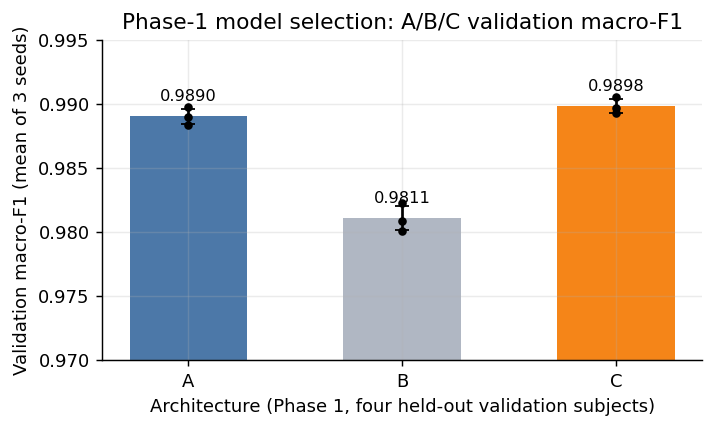

In [2]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
names = ['A', 'B', 'C']
means = [MODELS[m][2] for m in names]; stds = [MODELS[m][3] for m in names]
ax.bar(names, means, yerr=stds, capsize=4, color=['#4C78A8', '#B0B7C3', '#F58518'], width=0.55)
for i, m in enumerate(names):
    ax.scatter([i] * 3, MODELS[m][4], color='k', s=14, zorder=3)
    ax.text(i, means[i] + 0.0012, f"{means[i]:.4f}", ha='center', fontsize=9)
ax.set_ylim(0.970, 0.995); ax.set_ylabel('Validation macro-F1 (mean of 3 seeds)')
ax.set_xlabel('Architecture (Phase 1, four held-out validation subjects)')
ax.set_title('Phase-1 model selection: A/B/C validation macro-F1')
plt.tight_layout(); plt.show()

**Reading the result.** The predefined rule — *highest mean validation macro-F1* — selected **C**. The margin is small: C − A ≈ 0.0008, while the per-seed ranges of A and C overlap (A: 0.9883–0.9898; C: 0.9893–0.9905). With three seeds and four validation subjects **no statistical significance is claimed** for C over A.

**Engineering observation.** A reached almost the same validation performance with 3,766 parameters (vs 8,862) and 274,624 MAC/window (vs 415,296) — about 42% fewer parameters and 34% fewer MACs. For a wake-up application, A is a very attractive operating point; C was chosen because the selection rule was fixed in advance on accuracy alone.


## 7. Phase-2 Final Training

After selection, C was retrained on **all 7,352 official-train windows (21 subjects)**, with normalisation statistics recomputed on those windows only. Phase 2 has no validation set, so the epoch budget was fixed *before* any official-test evaluation from the Phase-1 rule: `round(mean(best epochs of C)) = round(mean([1, 1, 2])) = 1` epoch. Final seed: `123`. The final checkpoint (last epoch) is the one evaluated.

| Phase-2 quantity (`phase2_final_C_seed123_curves.json`) | Value |
|---|---:|
| Epochs | 1 |
| Training loss (during epoch) | 0.6508 |
| Training accuracy (during epoch) | 0.8424 |
| Evaluation pass on the training windows: loss | 0.2300 |
| Evaluation pass on the training windows: accuracy | 0.9381 |
| Evaluation pass on the training windows: macro-F1 | 0.9409 |

The evaluation-pass numbers are computed on the training windows themselves (the log stores them under `val_*` keys because the same code path is reused); they are not held-out performance.

The fixed one-epoch budget is a *plausible contributor* to the validation→test gap discussed in §10 (possible undertraining), but this was **not** tested experimentally, and it must not be read as the established cause.


## 8. Frozen Official-Test Evaluation

> ### Selected Model C — one frozen evaluation on the official test set (2,947 windows, 9 unseen subjects)
> | Metric | Value |
> |---|---:|
> | **Accuracy** | **0.8870** (0.8870037326…) |
> | **Macro-F1** | **0.8864** (0.8864032939…) |
> | Weighted-F1 | 0.8876 (0.8876368363…) |

Per-class results (from `final_test_evaluation.json`):

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| WALKING | 0.9886 | 0.8730 | 0.9272 | 496 |
| WALKING_UPSTAIRS | 0.9606 | 0.8811 | 0.9192 | 471 |
| WALKING_DOWNSTAIRS | 0.7812 | 0.9690 | 0.8650 | 420 |
| SITTING | 0.8299 | 0.7454 | 0.7854 | 491 |
| STANDING | 0.7889 | 0.8571 | 0.8216 | 532 |
| LAYING | 1.0000 | 1.0000 | 1.0000 | 537 |

The evaluation was performed once, after the model and epoch budget were fixed; nothing in this notebook re-executes it.


## 9. Confusion Matrix and Failure Analysis

The heat map below is drawn from the saved confusion matrix (no inference was rerun).


total errors: 333 | accuracy: 0.887


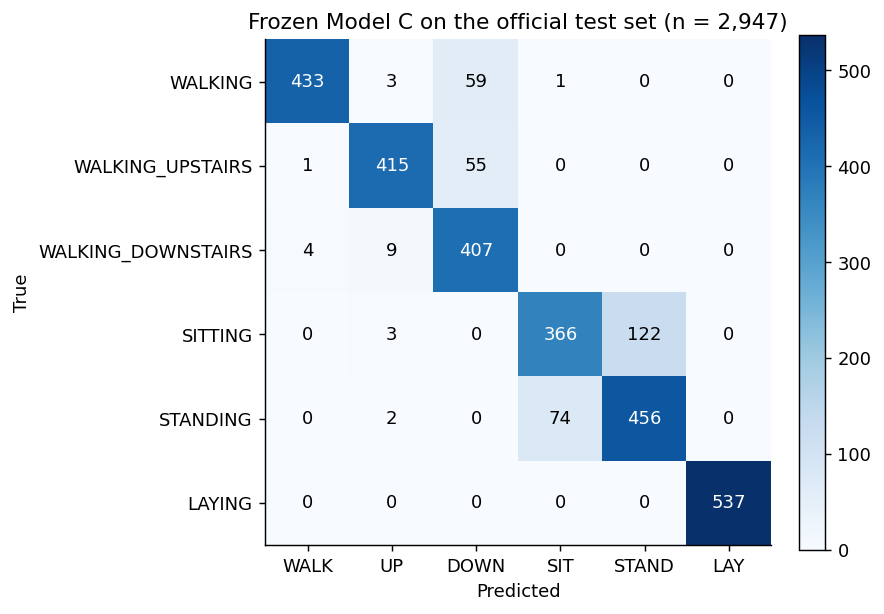

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(CONFUSION, cmap='Blues'); ax.grid(False)
short = ['WALK', 'UP', 'DOWN', 'SIT', 'STAND', 'LAY']
ax.set_xticks(range(6)); ax.set_xticklabels(short); ax.set_yticks(range(6)); ax.set_yticklabels(CLASSES)
for i in range(6):
    for j in range(6):
        ax.text(j, i, CONFUSION[i, j], ha='center', va='center', color='white' if CONFUSION[i, j] > 250 else 'black', fontsize=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Frozen Model C on the official test set (n = 2,947)')
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
err = CONFUSION.sum() - np.trace(CONFUSION)
print('total errors:', err, '| accuracy:', round(np.trace(CONFUSION) / CONFUSION.sum(), 4))

**Measured error structure (333 errors of 2,947 windows)**

| Largest confusions | Count | Share of true class |
|---|---:|---:|
| SITTING → STANDING | 122 | 24.8% of SITTING |
| STANDING → SITTING | 74 | 13.9% of STANDING |
| WALKING → WALKING_DOWNSTAIRS | 59 | 11.9% of WALKING |
| WALKING_UPSTAIRS → WALKING_DOWNSTAIRS | 55 | 11.7% of UPSTAIRS |

| Error grouping | Errors | Fraction |
|---|---:|---:|
| Within static (SIT/STAND/LAY) | 196 | 58.86% |
| Within dynamic (WALK/UP/DOWN) | 131 | 39.34% |
| Across static ↔ dynamic | 6 | 1.80% |

**Interpretation.** Almost all errors stay inside the broad static or dynamic group; the coarse static/dynamic distinction is largely resolved. The main weakness is **SITTING ↔ STANDING**. Among dynamic classes, mistakes lean toward **WALKING_DOWNSTAIRS**, which therefore has high recall (≈ 96.9%) but the lowest precision among the dynamic classes (≈ 78.1%). **LAYING was classified perfectly on this test set**; this says nothing about other subjects or datasets. No causal or biomechanical explanation for these patterns was tested, so none is offered.


## 10. Validation–Test Gap

| Evaluation | Macro-F1 |
|---|---:|
| Model C, Phase-1 validation (4 subjects, mean of 3 seeds) | ≈ 98.98% |
| Model C, frozen official test (9 subjects, single run) | ≈ 88.64% |
| **Gap** | **≈ 10.3 percentage points** |

Note the evaluations differ in subjects, training-set composition (5,879 vs 7,352 windows) and protocol (three seeds/best checkpoint vs one seed/one epoch), so the gap is a descriptive contrast rather than a controlled comparison.

**Candidate explanations — hypotheses, not established causes:**

1. *Subject-to-subject generalisation:* activity signatures differ across people, and a model can score highly on some subjects yet transfer less well to others.
2. *Only four validation subjects:* the Phase-1 estimate has high variance and may be optimistic; the per-subject spread in §16 (0.972–1.000 for C) already shows heterogeneity.
3. *Different difficulty of validation vs test subjects.*
4. *Possible undertraining* under the fixed one-epoch Phase-2 protocol.

Separating these would require grouped subject-level cross-validation and a Phase-2 protocol study (both future work). The gap is reported as a limitation of the current evidence rather than something to explain away.


## 11. Streaming and Embedded-System Analysis (derived, not measured)

For Model C at 50 Hz with the native UCI HAR window schedule:

| Quantity | Value | Basis |
|---|---:|---|
| Window length | 128 samples = 2.56 s | dataset |
| Hop | 64 samples = 1.28 s | dataset |
| Decision rate | 1 / 1.28 s = **0.78125 decisions/s** | derived |
| MAC/window | 415,296 | computed (§5) |
| MAC rate at this schedule | 415,296 × 0.78125 ≈ **324,450 MAC/s** | derived |
| Sensor stream | 6 × 50 = 300 values/s | derived |
| Stream bandwidth, float32 | ≈ 1,200 B/s | derived |
| Stream bandwidth, int16 (hypothetical sensor format) | ≈ 600 B/s | hypothetical |
| Raw float32 window | 6 × 128 × 4 = 3,072 B ≈ 3 KiB | derived |

**What the current code is — and is not.** The Python implementation is a *sliding-window classifier*: it buffers a full window and recomputes everything per hop.

- 50% overlapping windows do **not** automatically imply 50% compute reuse; without persistent state the shared half is reprocessed.
- A/B/C use symmetric ("same") padding, which is non-causal (outputs depend on future samples), and max-pooling adds shape-dependent bookkeeping.
- A true streaming implementation would need persistent per-layer state / ring buffers, causal padding and incremental execution, plus a running aggregation in place of window-level GAP.
- BN folding, quantisation, DMA/FIFO integration and similar steps are **future implementation directions**, not measured results.

**Conceptual mapping (not implemented):**

`sensor → DMA/FIFO → chunk / ring buffer → incremental feature extraction → aggregation → classifier → wake / interrupt`

**Not measured:** X-HEEP or any MCU cycles, latency, energy, DMA speedup, memory traffic, or quantised accuracy.


## 12. Research Extension (validation-only)

> **Scope.** Everything in §12–§17 uses only the Phase-1 train/validation subjects. **No extension model was evaluated on the frozen official test set.** The official test remained untouched, and the extension package is protected by a static forbidden-symbol scan and a before/after hash check of the frozen artifacts.

The extension was designed to probe questions the minimum assignment does not answer:

1. Is nonlinear temporal feature extraction useful relative to a raw linear baseline?
2. What changes when the backbone is explicitly **causal**?
3. Which sensor components contribute most under this protocol?
4. How do models compare when accuracy, compute and parameter count are considered together?
5. How variable is validation performance across individual held-out subjects?

Protocol for all new models: identical split, normalisation (train-only; refit per channel subset for ablations), optimiser, batch size, early stopping, checkpoint rule and seeds `[0, 1, 2]` as Phase 1.


## 13. Linear Baseline

Flatten the `(6, 128)` window to 768 values and apply `Linear(768→6)`.

| Model | Params | MAC/window | Temporal dependence | Mean val macro-F1 |
|---|---:|---:|---|---:|
| Linear | 4,614 | 4,608 | full-window dependence | 0.6203 ± 0.0013 |

Its temporal dependence is described as *full-window dependence* (every output reads all 128 samples) rather than a convolutional receptive field of 128.

Under this protocol, a raw linear classifier is far below the compact CNNs (≈ 0.62 vs ≈ 0.98–0.99 macro-F1). This supports the usefulness of learned nonlinear temporal representations *in this experiment*; it is not a universal statement about linear models.


## 14. Model D — Causal Dilated CNN

Model D belongs to the **research extension**, not to the original A/B/C selection stage. It is built from four causal depthwise-separable stages (kernel 5, dilation 1/2/4/8, stride 1, left-only zero padding of `dilation×(k−1)` samples, no pooling), followed by GAP and a linear layer.

| Stage | Channels | Depthwise (causal) | Pointwise | BN/ReLU |
|---|---|---|---|---|
| 1 | 6 → 16 | k5, dilation 1, groups 6 | 6→16 | 16 |
| 2 | 16 → 24 | k5, dilation 2, groups 16 | 16→24 | 24 |
| 3 | 24 → 32 | k5, dilation 4, groups 24 | 24→32 | 32 |
| 4 | 32 → 48 | k5, dilation 8, groups 32 | 32→48 | 48 |
| Head | GAP → Linear 48→6 | | | |

*(As implemented in `experiments/research_extension/architectures_ext.py`, each stage is a causal depthwise convolution over the stage's input channels followed by a 1×1 pointwise convolution; the parameter count 3,906 below is reproduced by this structure.)*

**Local receptive field:** `RF = 1 + 4·(1 + 2 + 4 + 8) = 61` samples.

| Model | Params | MAC/window | Local RF | Causal backbone | Mean val macro-F1 |
|---|---:|---:|---:|---|---:|
| A | 3,766 | 274,624 | 18 | no | 0.9890 ± 0.0006 |
| D | 3,906 | 406,560 | 61 | yes | 0.9778 ± 0.0062 |

D shows that a causal backbone with a 61-sample local receptive field and fewer than 4k parameters can retain high validation performance. **However, A remains better on the measured validation-F1 / parameter / MAC trade-off** (higher F1, fewer parameters, fewer MACs), so A dominates D on those axes. D's value is the architectural property — explicit causality and a larger local temporal context — not a better score. D was never evaluated on the official test set, and its validation macro-F1 must not be compared with C's official-test macro-F1, which comes from a different evaluation population.

Caveat on streaming: D's backbone is causal, but the GAP + Linear head is still a window-level decision, so D is not by itself a complete streaming system. A purely algorithmic state estimate (ring buffers: 1,560 scalars + 120 transient scalars ≈ 1,680 scalars ≈ 6,720 B in float32) is recorded in the repository; it is a count, not an MCU measurement.


## 15. Sensor Ablation

Controlled architecture: **Model A** (chosen in advance as the cheapest of the frozen models whose validation score was within one std of C). Each arm refits its own per-channel normalisation on its own training windows; 3-channel arms necessarily have a smaller first layer.

| Input | Channels | Params | MAC/window | Mean val macro-F1 |
|---|---:|---:|---:|---:|
| total_acc + gyro | 6 | 3,766 | 274,624 | 0.9890 ± 0.0006 |
| total_acc only | 3 | 3,334 | 219,328 | 0.9684 ± 0.0039 |
| gyro only | 3 | 3,334 | 219,328 | 0.7338 ± 0.0011 |
| body_acc + gyro | 6 | 3,766 | 274,624 | 0.8485 ± 0.0085 |

(The 6-channel `total_acc + gyro` arm is a retrained control that reproduces the Phase-1 A result.)


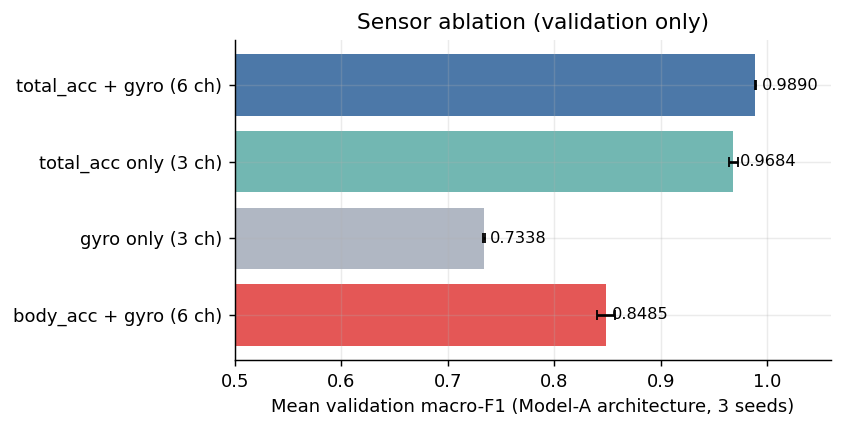

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
labs = list(ABLATION); means = [ABLATION[l][3] for l in labs]; stds = [ABLATION[l][4] for l in labs]
ax.barh(labs[::-1], means[::-1], xerr=stds[::-1], capsize=3, color=['#E45756', '#B0B7C3', '#72B7B2', '#4C78A8'])
for i, v in enumerate(means[::-1]): ax.text(v + 0.006, i, f"{v:.4f}", va='center', fontsize=9)
ax.set_xlim(0.5, 1.06); ax.set_xlabel('Mean validation macro-F1 (Model-A architecture, 3 seeds)')
ax.set_title('Sensor ablation (validation only)'); plt.tight_layout(); plt.show()

Under this split, model and protocol:

- total acceleration alone retained much of the full-input performance (0.968 vs 0.989);
- gyroscope alone was substantially weaker (0.734);
- replacing total acceleration with body acceleration (gravity removed) substantially reduced validation performance (0.849).

Because total acceleration retains the gravity component, this is *consistent with* gravity/orientation information being useful for separating postures. It does **not** establish a causal physical mechanism, and it does not show that accelerometers are generally more informative than gyroscopes.


## 16. Per-Subject Validation Analysis

Mean-over-seeds macro-F1 on each of the four Phase-1 validation subjects (frozen A/C checkpoints and the extension-trained D/Linear, all on validation windows only):

| Model | Subject 1 | Subject 3 | Subject 25 | Subject 27 | Std across subjects |
|---|---:|---:|---:|---:|---:|
| A | 0.9992 | 0.9761 | 0.9823 | 0.9990 | 0.0102 |
| C | 1.0000 | 0.9894 | 0.9721 | 1.0000 | 0.0114 |
| D | 0.9964 | 0.9910 | 0.9304 | 0.9976 | 0.0281 |
| Linear | 0.5479 | 0.6570 | 0.5479 | 0.6795 | 0.0607 |


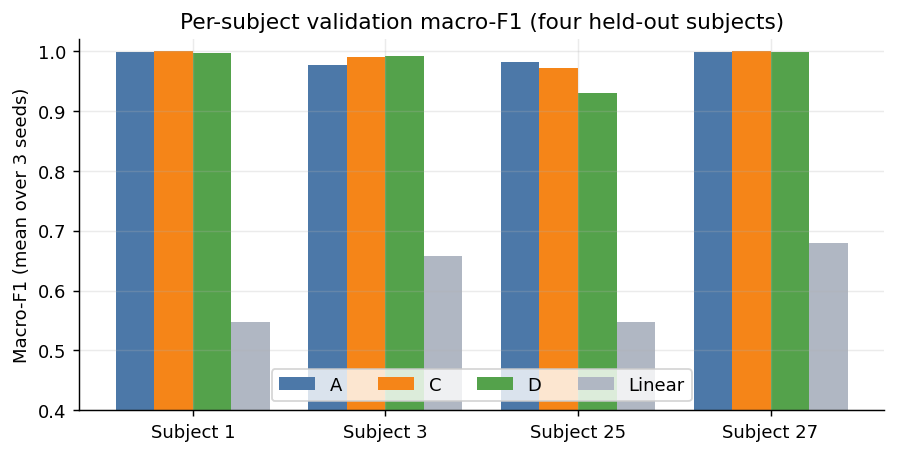

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.6))
w = 0.2; x = np.arange(len(SUBJECTS))
for i, (m, c) in enumerate(zip(['A', 'C', 'D', 'Linear'], ['#4C78A8', '#F58518', '#54A24B', '#B0B7C3'])):
    ax.bar(x + (i - 1.5) * w, PER_SUBJECT[m], w, label=m, color=c)
ax.set_xticks(x); ax.set_xticklabels([f"Subject {s}" for s in SUBJECTS]); ax.set_ylim(0.4, 1.02)
ax.set_ylabel('Macro-F1 (mean over 3 seeds)'); ax.legend(ncol=4, loc='lower center')
ax.set_title('Per-subject validation macro-F1 (four held-out subjects)'); plt.tight_layout(); plt.show()

D showed greater variability across **these four** validation subjects than A or C, mainly because of subject 25 (0.930). The hardest subject differs by model (A: subject 3; C, D: subject 25), and with only four subjects nothing here generalises to the wider population. Broader grouped subject-level cross-validation is future work (a 7-fold × 3-subject design is proposed in the repository but was **not run**).


## 17. Pareto Analysis

Model X *dominates* model Y if X has validation macro-F1 at least as high and cost at most as high, with at least one strict inequality. A model is *non-dominated* if no other model dominates it.

| Cost axis | Non-dominated | Dominated |
|---|---|---|
| MAC/window | Linear, A, C | B (by A and C), D (by A) |
| Parameters | A, C | B (by A and C), D (by A), Linear (by A and D) |

(Dominated/non-dominated statuses match `pareto` in the saved extension summary, which lists one dominating model per entry; the code cell below recomputes all dominators from the embedded values as a consistency check.)


Dominated by (MAC/window): {'Linear': [], 'A': [], 'B': ['A', 'C'], 'C': [], 'D': ['A']}
Dominated by (params)   : {'Linear': ['A', 'D'], 'A': [], 'B': ['A', 'C'], 'C': [], 'D': ['A']}


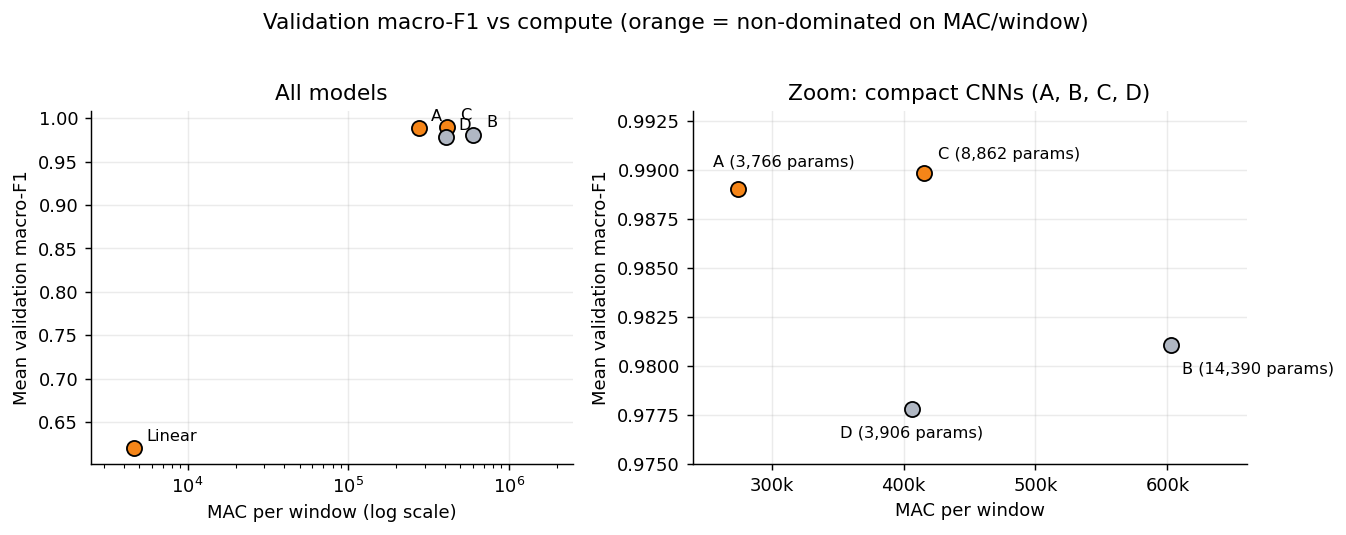

In [6]:
def dominated(m, cost_idx):
    f = MODELS[m][2]
    return [o for o in MODELS if o != m and MODELS[o][cost_idx] <= MODELS[m][cost_idx] and MODELS[o][2] >= f
            and (MODELS[o][cost_idx] < MODELS[m][cost_idx] or MODELS[o][2] > f)]
dom_mac = {m: dominated(m, 1) for m in MODELS}
dom_par = {m: dominated(m, 0) for m in MODELS}
print('Dominated by (MAC/window):', {m: v for m, v in dom_mac.items()})
print('Dominated by (params)   :', {m: v for m, v in dom_par.items()})
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), gridspec_kw={'width_ratios': [1, 1.15]})
OFF = {'Linear': (8, 6), 'A': (-14, 12), 'B': (6, -16), 'C': (8, 8), 'D': (-40, -16)}
for ax, zoom in zip(axes, [False, True]):
    for m, (p, mac, f, s, _) in MODELS.items():
        if zoom and m == 'Linear': continue
        ax.scatter(mac, f, s=70, color='#F58518' if not dom_mac[m] else '#B0B7C3', edgecolor='k', zorder=3)
        ax.annotate(f"{m} ({p:,} params)" if zoom else m, (mac, f), textcoords='offset points', xytext=OFF[m] if zoom else (7, 4), fontsize=9)
    ax.set_xlabel('MAC per window' + ('' if zoom else ' (log scale)')); ax.set_ylabel('Mean validation macro-F1')
axes[0].set_xscale('log'); axes[0].set_xlim(2.5e3, 2.5e6); axes[0].set_title('All models')
axes[1].set_xlim(2.4e5, 6.6e5); axes[1].set_xticks([3e5, 4e5, 5e5, 6e5]); axes[1].set_xticklabels(['300k', '400k', '500k', '600k']); axes[1].set_ylim(0.975, 0.993); axes[1].set_title('Zoom: compact CNNs (A, B, C, D)')
fig.suptitle('Validation macro-F1 vs compute (orange = non-dominated on MAC/window)', y=1.02)
plt.tight_layout(); plt.show()

Model complexity did not improve validation performance monotonically: B (largest) is dominated by A, and D is dominated by A. A is especially attractive from an accuracy-cost perspective. C was nevertheless the model selected by the original, predefined accuracy-based rule, and that choice was not revised after seeing the extension.


## 18. Discussion

**What worked**

- Raw IMU windows, with no handcrafted features, support strong classification; the < 20k-parameter constraint is met comfortably (3.8k–14.4k).
- A and C reach ≈ 0.99 validation macro-F1 on held-out subjects.
- On the frozen test, coarse static/dynamic separation is strong (only 6 of 333 errors cross the boundary).
- The compact depthwise-separable design (C) works well; a causal D keeps ≈ 0.978 validation macro-F1 with < 4k parameters.

**What did not work perfectly**

- The validation→test gap of ≈ 10 percentage points.
- SITTING ↔ STANDING confusion, and dynamic errors leaning toward WALKING_DOWNSTAIRS.
- Larger models were not necessarily better (B < A); causal D needs more MACs than A at a similar parameter count.

**Engineering lesson.** Accuracy alone is not enough for a wake-up network. Parameters, MACs, activation/state memory, causality, sensor choice, subject robustness and — eventually — measured hardware behaviour must be considered jointly. Parameter count and compute are distinct axes (D has ≈ A's parameters but ≈ 1.5× its MACs).


## 19. Limitations

Boundaries of the current evidence:

- One dataset (UCI HAR).
- Four validation subjects in the primary development split; only three seeds.
- No broad grouped subject-level cross-validation.
- A substantial validation→official-test gap that was not diagnosed.
- A fixed one-epoch Phase-2 retraining protocol, with no ablation of the epoch budget.
- No int8 / fixed-point accuracy evaluation.
- No embedded C implementation and no true persistent streaming execution.
- No measured MCU latency, cycles or energy, and no measured DMA/FIFO benefit.
- Research-extension models (Linear, D, ablations) have no official-test results by design.


## 20. Future Work

1. Broader grouped subject-level validation (e.g. the proposed 7-fold × 3-subject scheme).
2. A true stateful causal streaming implementation, with running aggregation replacing window-level GAP.
3. Quantisation and fixed-point accuracy evaluation.
4. An embedded C implementation.
5. Deployment and benchmarking on X-HEEP.
6. Measurement of cycles, latency, memory and energy.
7. Causal architectures with lower MAC count than D.
8. Binary or event-oriented wake-up tasks, if aligned with the target application.


## 21. Conclusion

The project moved from building a small activity classifier to examining accuracy, computation, model size, causality, sensor information and subject variability together.

Model C was selected under the predetermined validation rule and, in the single frozen evaluation, reached **88.70% official-test accuracy and 88.64% macro-F1**. Model A remained especially attractive from a validation accuracy-cost perspective (≈ same validation F1 with fewer parameters and MACs), without any claim of significance over C.

The validation-only extension showed that: a raw linear baseline (0.620) is insufficient for comparable performance; a < 4k-parameter causal dilated backbone can retain high validation performance (0.978); sensor choice matters substantially under this protocol (total-acc-only 0.968, gyro-only 0.734, body-acc + gyro 0.849); model size and compute are distinct design dimensions; and causality alone does not make a complete streaming implementation.

The next meaningful step is therefore not simply a larger network, but true stateful execution and hardware measurement.

---
### Appendix — provenance notes

- All figures use values copied from `results/metrics/*.json` and `results/research_extension/metrics/research_extension_summary.json`.
- `report/research_extension.md` in the repository is a pre-run design document whose result cells read "NOT YET MEASURED"; the measured values in this notebook come from the saved summary JSON and `research_extension_tables.md`, which supersede it.
- Where the request's description of Model D's first layer (a dense `Conv 6→16`) differs from the repository, the repository was followed: stage 1 is a causal depthwise conv on the 6 input channels followed by a 6→16 pointwise conv (3,906 parameters reproduced by hand).
